In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing :

In [7]:
data = pd.read_csv('amazonreviews.tsv',sep="\t")

In [8]:
data.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [9]:
data.shape

(10000, 2)

In [10]:
data.columns

Index(['label', 'review'], dtype='object')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [12]:
data.isnull().sum()

label     0
review    0
dtype: int64

In [13]:
data['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

- The dataset contains 10,000 Amazon customer reviews, with 5,097 negative reviews (50.97%) and 4,903 positive reviews (49.03%).
- Since the class distribution is nearly balanced, no additional balancing techniques were required before training the sentiment classification model.

In [14]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


#### Duplicate Values: 
- The dataset was checked for duplicate records using the duplicated() function. 
- No duplicate reviews were found; therefore, no duplicate removal was required.

### Exploratory Data Analysis :

In [15]:
import nltk

In [16]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data['clean_review'] = data['review'].apply(clean_text)

data[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


### Sentiment Distribution :

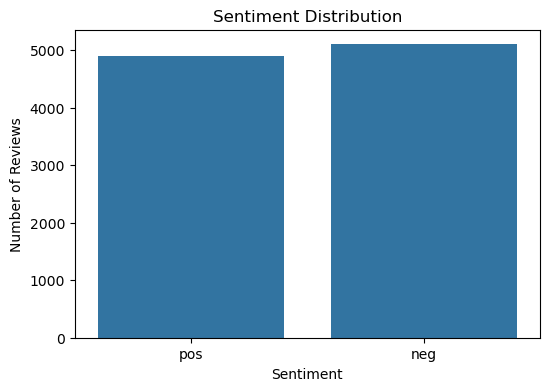

In [18]:

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=data)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Word Cloud :

In [19]:
!pip install wordcloud

In [20]:
from wordcloud import WordCloud

#### Positive Reviews Word Cloud :

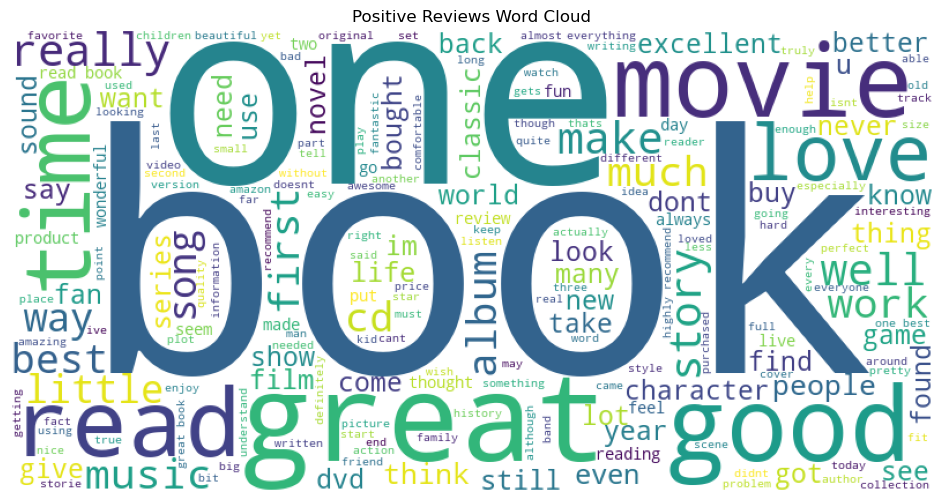

In [21]:
positive_reviews = " ".join(data[data['label']=='pos']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

#### Negative Reviews Word Cloud :

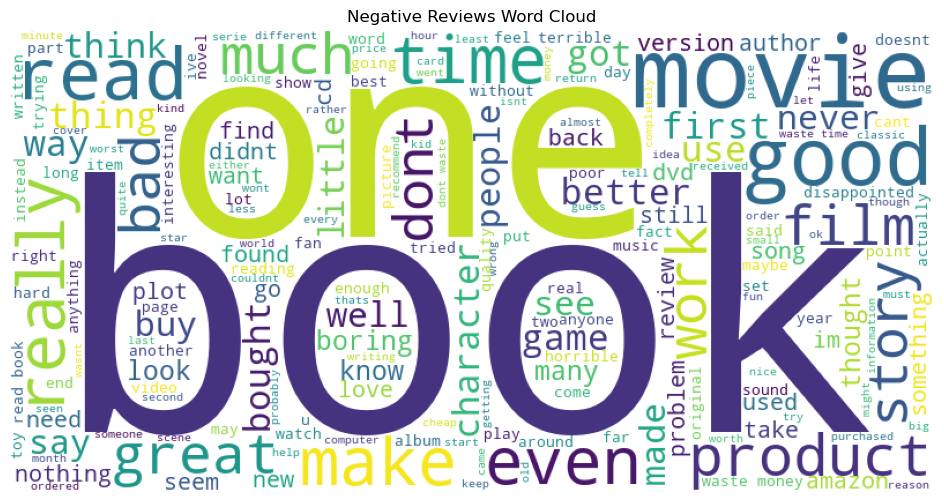

In [22]:
negative_reviews = " ".join(data[data['label']=='neg']['clean_review'])

wordcloud = WordCloud(width=800,height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

- The word clouds highlight the most frequently occurring words in positive and negative reviews.
- Larger words indicate higher frequency, helping visualize common customer opinions.

### Most Frequent Words :

In [23]:
from collections import Counter

#### Positive Review :

In [24]:
positive_words = " ".join(data[data['label']=='pos']['clean_review']).split()

positive_freq = Counter(positive_words)

print(positive_freq.most_common(20))

[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871), ('well', 854), ('really', 827), ('best', 801), ('get', 793), ('story', 713), ('first', 708), ('much', 650), ('cd', 581), ('music', 559), ('also', 557)]


#### Negative Review :

In [25]:
negative_words = " ".join(data[data['label']=='neg']['clean_review']).split()

negative_freq = Counter(negative_words)

print(negative_freq.most_common(20))

[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034), ('even', 898), ('buy', 814), ('really', 778), ('much', 769), ('bad', 749), ('money', 744), ('first', 736), ('could', 658), ('better', 656), ('great', 632)]


#### Bar Chart of Most Frequent Positive Words :

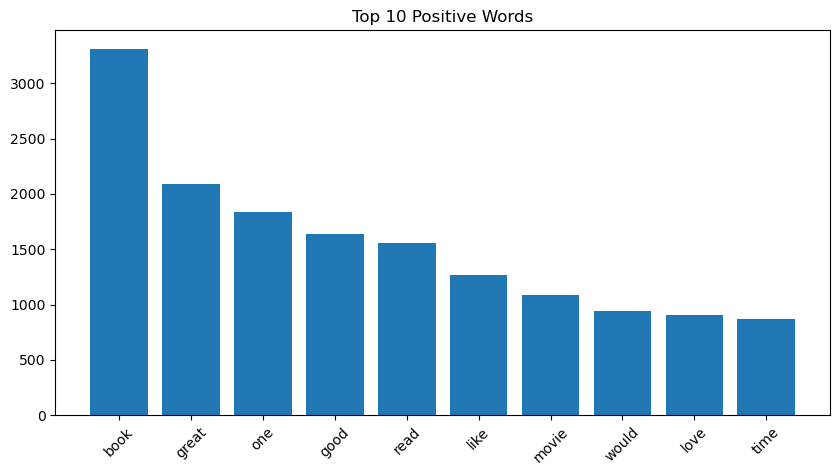

In [26]:
top_positive = positive_freq.most_common(10)

words = [i[0] for i in top_positive]
counts = [i[1] for i in top_positive]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Top 10 Positive Words")
plt.xticks(rotation=45)

plt.show()

#### Bar Chart of Most Frequent Negative Words :

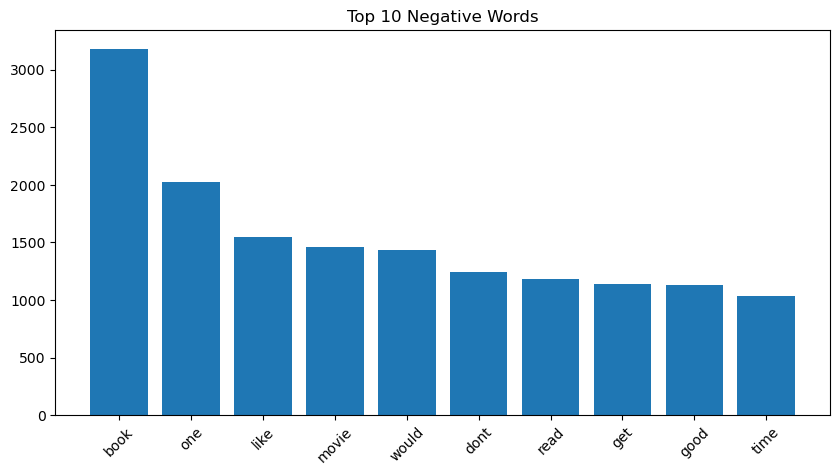

In [27]:
top_negative = negative_freq.most_common(10)

words = [i[0] for i in top_negative]
counts = [i[1] for i in top_negative]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Top 10 Negative Words")
plt.xticks(rotation=45)

plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_review'])

y = data['label']

In [31]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:20])

[1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0]


### Train-Test Split :

In [34]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,random_state = 42, stratify=y)

### Train Logistic Regression Model :

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Make Predictions :

In [38]:
y_pred = model.predict(X_test)

### Evaluate the Model :

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.853
Precision: 0.8523076923076923
Recall   : 0.8470948012232415
F1 Score : 0.8496932515337423

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1019
           1       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix
[[875 144]
 [150 831]]


### Cross Validation :

In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.8595 0.835  0.83   0.829  0.851 ]
Average Accuracy: 0.8409000000000001
